# Klientų nutekėjimo analizė

**Tajus Davidavičius** | Duomenų analitika, 2026

Analizuoju telekomo kompanijos klientų nutekėjimą (*churn*) — kodėl ir kada klientai nutraukia sutartį ir išeina pas kitą operatorių.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

duomenys = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

print("Eiluciu skaicius:", duomenys.shape[0])
print("Stulpeliu skaicius:", duomenys.shape[1])
duomenys.head()

Eiluciu skaicius: 7043
Stulpeliu skaicius: 21


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [2]:
duomenys.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [3]:
tuscios = duomenys["TotalCharges"].str.strip() == ""
print("Kiek tusciu reiksmiu:", tuscios.sum())

duomenys.loc[tuscios, ["customerID", "tenure", "MonthlyCharges", "TotalCharges", "Churn"]]

Kiek tusciu reiksmiu: 11


,customerID,tenure,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,0,52.55,,No
753,3115-CZMZD,0,20.25,,No
936,5709-LVOEQ,0,80.85,,No
1082,4367-NUYAO,0,25.75,,No
1340,1371-DWPAZ,0,56.05,,No
3331,7644-OMVMY,0,19.85,,No
3826,3213-VVOLG,0,25.35,,No
4380,2520-SGTTA,0,20.00,,No
5218,2923-ARZLG,0,19.70,,No
6670,4075-WKNIU,0,73.35,,No


In [4]:
duomenys["TotalCharges"] = pd.to_numeric(duomenys["TotalCharges"], errors="coerce")

print("Trukstamu reiksmiu po konvertavimo:", duomenys["TotalCharges"].isnull().sum())

duomenys = duomenys.dropna(subset=["TotalCharges"])

print("Eiluciu po valymo:", duomenys.shape[0])
print("TotalCharges tipas:", duomenys["TotalCharges"].dtype)

Trukstamu reiksmiu po konvertavimo: 11
Eiluciu po valymo: 7032
TotalCharges tipas: float64



## 1. Duomenų įkėlimas

**Kas yra churn?** Klientas nutraukia sutartį ir išeina pas kitą operatorių.

**Kodėl tai svarbu?** Naujo kliento pritraukimas kainuoja kelis kartus
brangiau nei esamo išlaikymas. Jei operatorius žino iš anksto, kas
ruošiasi išeiti, gali spėti pasiūlyti nuolaidą.

**Duomenys:** 7043 telekomo klientai, 21 stulpelis (po valymo – 7032).
Kiekviena eilutė – vienas klientas: sutarties tipas, kiek moka,
kiek laiko klientas, kokias paslaugas turi, ar išėjo.

## 2. Duomenų valymas
`TotalCharges` įkėliau kaip tekstą, nes 11 įrašų vietoj skaičiaus turėjo tarpą.
Visų 11 klientų `tenure = 0` — tai nauji klientai, dar negavę sąskaitos.
Eilutės pašalintos (0,16% duomenų, nė vienas iš jų nebuvo išėjęs klientas).

In [5]:
print(duomenys["Churn"].value_counts())
print()
print(duomenys["Churn"].value_counts(normalize=True).round(3) * 100)

Churn
No     5163
Yes    1869
Name: count, dtype: int64

Churn
No     73.4
Yes    26.6
Name: proportion, dtype: float64


## 2.5 Duomenų aprašomoji statistika

Prieš tikrinant hipotezes — kaip atrodo pagrindiniai kintamieji ir kiek jie varijuoja.

In [6]:
print(duomenys[["tenure", "MonthlyCharges", "TotalCharges"]].describe().round(1))

       tenure  MonthlyCharges  TotalCharges
count  7032.0          7032.0        7032.0
mean     32.4            64.8        2283.3
std      24.5            30.1        2266.8
min       1.0            18.2          18.8
25%       9.0            35.6         401.4
50%      29.0            70.4        1397.5
75%      55.0            89.9        3794.7
max      72.0           118.8        8684.8


In [7]:
for stulpelis in ["Contract", "InternetService", "PaymentMethod"]:
    print(f"--- {stulpelis} ---")
    print((duomenys[stulpelis].value_counts(normalize=True) * 100).round(1))
    print()

--- Contract ---
Contract
Month-to-month    55.1
Two year          24.0
One year          20.9
Name: proportion, dtype: float64

--- InternetService ---
InternetService
Fiber optic    44.0
DSL            34.4
No             21.6
Name: proportion, dtype: float64

--- PaymentMethod ---
PaymentMethod
Electronic check             33.6
Mailed check                 22.8
Bank transfer (automatic)    21.9
Credit card (automatic)      21.6
Name: proportion, dtype: float64



## Metodika

Kiekvienai hipotezei tikrinti naudoju skirtingą metodą, priklausomai
nuo kintamųjų tipo:

- **Chi-kvadrato testas** – kai lyginu du kategorinius kintamuosius
  (pvz. sutarties tipas ir ar klientas išėjo).
- **T-testas** – kai lyginu skaitinį kintamąjį tarp dviejų grupių
  (pvz. mokestis tarp likusių ir išėjusių).
- **`pd.cut`** – klientavimo trukmę suskirstau į intervalus, kad
  matyčiau tendenciją, ne tik du skaičius.

Visur šalia procentų pateikiu p-reikšmę – patikrinti, ar skirtumas
tikrai reikšmingas, ar galėjo atsirasti atsitiktinai.

## 3. Hipotezė H1
**Kuo trumpesnis sutartinis įsipareigojimas, tuo didesnė nutekėjimo tikimybė.**

In [8]:
lentele = pd.crosstab(duomenys["Contract"], duomenys["Churn"])
print(lentele)
print()

procentai = pd.crosstab(duomenys["Contract"], duomenys["Churn"], normalize="index") * 100
print(procentai.round(1))

Churn             No   Yes
Contract                  
Month-to-month  2220  1655
One year        1306   166
Two year        1637    48

Churn             No   Yes
Contract                  
Month-to-month  57.3  42.7
One year        88.7  11.3
Two year        97.2   2.8


In [9]:
from scipy.stats import chi2_contingency

chi2, p, laisves_laipsniai, laukiamos = chi2_contingency(lentele)

print("Chi-kvadrato statistika:", round(chi2, 2))
print("p-reiksme:", p)

Chi-kvadrato statistika: 1179.55
p-reiksme: 7.326182186265472e-257


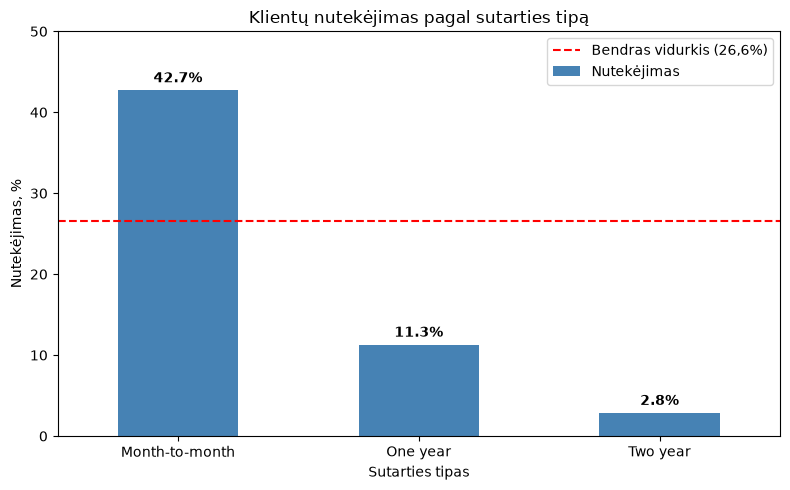

In [10]:
ax = procentai["Yes"].plot(kind="bar", color="steelblue", figsize=(8, 5), label="Nutekėjimas")

plt.title("Klientų nutekėjimas pagal sutarties tipą")
plt.xlabel("Sutarties tipas")
plt.ylabel("Nutekėjimas, %")
plt.xticks(rotation=0)
plt.ylim(0, 50)

plt.axhline(y=26.6, color="red", linestyle="--", label="Bendras vidurkis (26,6%)")

for i, reiksme in enumerate(procentai["Yes"]):
    plt.text(i, reiksme + 1, f"{reiksme:.1f}%", ha="center", fontweight="bold")

plt.legend()
plt.tight_layout()
plt.savefig("h1_sutartys.png", dpi=150, bbox_inches="tight")
plt.show()

**H1 – pasitvirtino.**
Mėnesinė sutartis: išeina 42,7%. Metinė: 11,3%. Dvejų metų: 2,8%.
Skirtumas 15 kartų. Chi-kvadratas patvirtino, kad ne atsitiktinumas.

Bet: neaišku, kas ką lemia. Gal sutartis laiko klientą, o gal
lojalūs žmonės tiesiog patys renkasi ilgesnę sutartį.

## 4. Hipotezė H2
**Išėję klientai mokėjo daugiau per mėnesį nei likusieji.**

In [11]:
suvestine = duomenys.groupby("Churn")["MonthlyCharges"].agg(["count", "mean", "median", "std"])
print(suvestine.round(2))

       count   mean  median    std
Churn                             
No      5163  61.31   64.45  31.09
Yes     1869  74.44   79.65  24.67


In [12]:
from scipy.stats import ttest_ind

iseje = duomenys[duomenys["Churn"] == "Yes"]["MonthlyCharges"]
liko = duomenys[duomenys["Churn"] == "No"]["MonthlyCharges"]

t_statistika, p_reiksme = ttest_ind(iseje, liko, equal_var=False)

print("t statistika:", round(t_statistika, 2))
print("p-reiksme:", p_reiksme)
print("Skirtumas:", round(iseje.mean() - liko.mean(), 2), "USD")

t statistika: 18.34
p-reiksme: 2.657357144516046e-72
Skirtumas: 13.13 USD


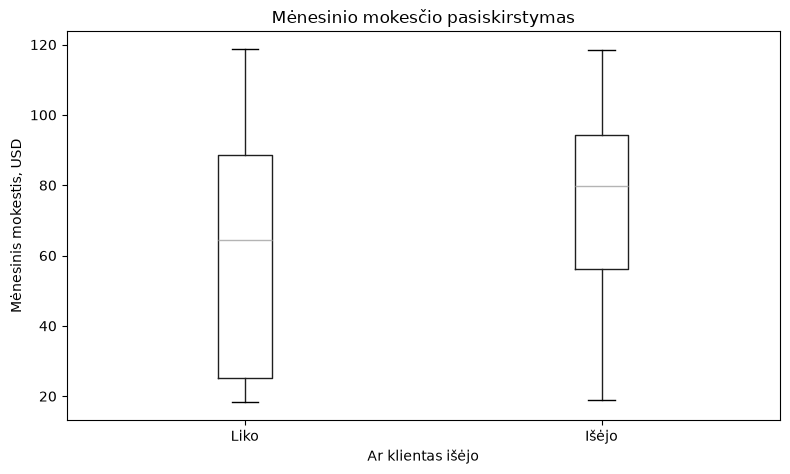

In [13]:
duomenys.boxplot(column="MonthlyCharges", by="Churn", figsize=(8, 5), grid=False)

plt.title("Mėnesinio mokesčio pasiskirstymas")
plt.suptitle("")
plt.xlabel("Ar klientas išėjo")
plt.ylabel("Mėnesinis mokestis, USD")
plt.xticks([1, 2], ["Liko", "Išėjo"])
plt.tight_layout()
plt.savefig("h2_mokestis.png", dpi=150, bbox_inches="tight")
plt.show()

In [14]:
print(pd.crosstab(duomenys["InternetService"], duomenys["Churn"], normalize="index").round(3) * 100)
print()
print(duomenys.groupby("InternetService")["MonthlyCharges"].mean().round(2))

Churn              No   Yes
InternetService            
DSL              81.0  19.0
Fiber optic      58.1  41.9
No               92.6   7.4

InternetService
DSL            58.09
Fiber optic    91.50
No             21.08
Name: MonthlyCharges, dtype: float64


**H2 – pasitvirtino.**
Išėjusieji mokėjo 74,44 USD, likusieji 61,31 USD. Skirtumas 13 USD.

Bet kaina čia greičiausiai ne priežastis. Optikos klientai moka
daugiausiai (91,50) ir bėga daugiausiai (41,9%). Kas neturi interneto –
moka 21 USD ir beveik nebėga (7,4%). Tai ne kaina kalta, o paslaugos tipas.

## 5. Hipotezė H3
**Naujausi klientai išeina dažniausiai — pirmieji mėnesiai kritiniai.**

In [15]:
print(duomenys.groupby("Churn")["tenure"].agg(["mean", "median"]).round(1))
print()

iseje_tenure = duomenys[duomenys["Churn"] == "Yes"]["tenure"]
liko_tenure = duomenys[duomenys["Churn"] == "No"]["tenure"]

t_stat, p_val = ttest_ind(iseje_tenure, liko_tenure, equal_var=False)
print("t statistika:", round(t_stat, 2))
print("p-reiksme:", p_val)

       mean  median
Churn              
No     37.7    38.0
Yes    18.0    10.0

t statistika: -34.97
p-reiksme: 2.34707471889502e-234


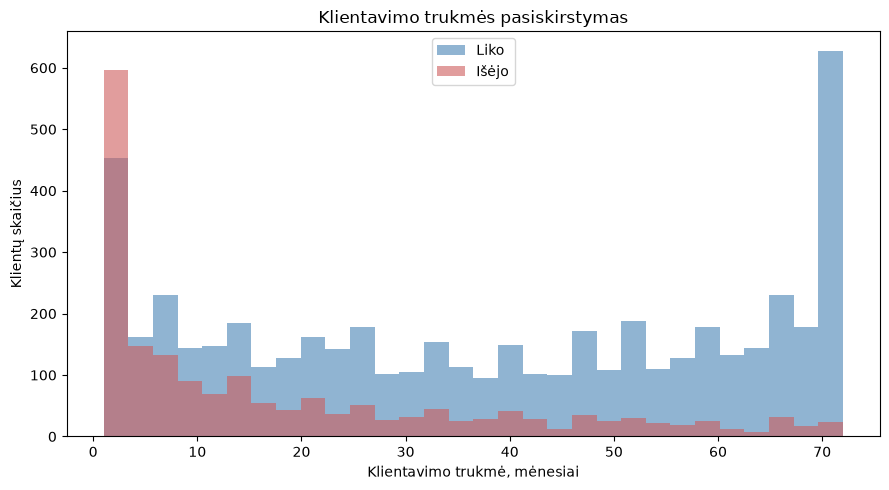

In [16]:
plt.figure(figsize=(9, 5))

plt.hist(liko_tenure, bins=30, alpha=0.6, label="Liko", color="steelblue")
plt.hist(iseje_tenure, bins=30, alpha=0.6, label="Išėjo", color="indianred")

plt.title("Klientavimo trukmės pasiskirstymas")
plt.xlabel("Klientavimo trukmė, mėnesiai")
plt.ylabel("Klientų skaičius")
plt.legend()
plt.tight_layout()
plt.savefig("h3_trukme.png", dpi=150, bbox_inches="tight")
plt.show()

In [17]:
grupes = pd.cut(duomenys["tenure"], bins=[0, 12, 24, 48, 72], 
                labels=["0-12", "13-24", "25-48", "49-72"])

churn_pagal_trukme = duomenys.groupby(grupes, observed=True)["Churn"].apply(
    lambda x: (x == "Yes").mean() * 100
)

print(churn_pagal_trukme.round(1))

tenure
0-12     47.7
13-24    28.7
25-48    20.4
49-72     9.5
Name: Churn, dtype: float64


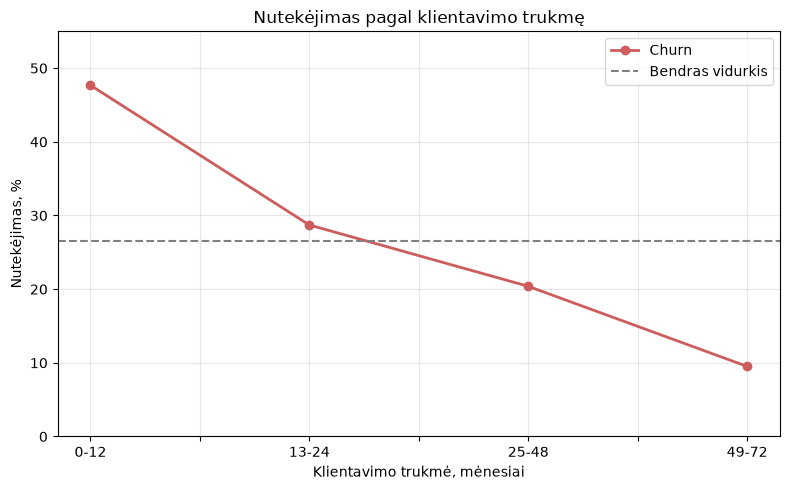

In [18]:
plt.figure(figsize=(8, 5))

churn_pagal_trukme.plot(kind="line", marker="o", linewidth=2, color="indianred")

plt.title("Nutekėjimas pagal klientavimo trukmę")
plt.xlabel("Klientavimo trukmė, mėnesiai")
plt.ylabel("Nutekėjimas, %")
plt.axhline(y=26.6, color="gray", linestyle="--", label="Bendras vidurkis")
plt.ylim(0, 55)
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig("h3_trukme_procentai.png", dpi=150, bbox_inches="tight")
plt.show()

**H3 – pasitvirtino, ir stipriausiai iš visų.**
Pirmais metais išeina 47,7% klientų. Po ketverių metų – tik 9,5%.
Tipinis išėjęs klientas buvo su kompanija 10 mėnesių.

Visos trys hipotezės rodo tą patį žmogų: naujas klientas,
mėnesinė sutartis, brangi optika. Čia ir yra rizikos grupė.

## 6. Papildoma įžvalga: mokėjimo būdas

Ar mokėjimo būdas taip pat susijęs su nutekėjimu?

In [19]:
mokejimai = pd.crosstab(duomenys["PaymentMethod"], duomenys["Churn"], normalize="index") * 100
print(mokejimai.round(1))

Churn                        No   Yes
PaymentMethod                        
Bank transfer (automatic)  83.3  16.7
Credit card (automatic)    84.7  15.3
Electronic check           54.7  45.3
Mailed check               80.8  19.2


Įtariu, kad elektroninio čekio klientai tiesiog sutampa su mėnesinės sutarties klientais. Tikrinu:

In [20]:
print(pd.crosstab(duomenys["PaymentMethod"], duomenys["Contract"], normalize="index").round(3) * 100)

Contract                   Month-to-month  One year  Two year
PaymentMethod                                                
Bank transfer (automatic)            38.2      25.4      36.4
Credit card (automatic)              35.7      26.2      38.1
Electronic check                     78.2      14.7       7.1
Mailed check                         55.7      20.9      23.4


In [21]:
tik_menesine = duomenys[duomenys["Contract"] == "Month-to-month"]

print(pd.crosstab(tik_menesine["PaymentMethod"], tik_menesine["Churn"], normalize="index").round(3) * 100)

Churn                        No   Yes
PaymentMethod                        
Bank transfer (automatic)  65.9  34.1
Credit card (automatic)    67.2  32.8
Electronic check           46.3  53.7
Mailed check               68.4  31.6


Patikrinau vien tarp mėnesinių – čekis vis tiek 53,7%, kiti ~33%.
Tai ne vien sutartis, mokėjimo būdas irgi turi reikšmės.

## 7. Išvados

Trys stipriausi rizikos požymiai: 1.mėnesinė sutartis, 2.klientas naujas
(0–12 mėn.), 3.moka elektroniniu čekiu. Kiekvienas iš jų veikia
nepriklausomai nuo kitų patikrinau.

Kaina pati savaime nekalta tiesiog optikos klientai moka daugiau
ir bėga dažniau. Priežastis veikiausiai pati paslauga, ne kaina.

**Rekomendacija:** pirmus 3 mėnesius stebėti tokį klientą ir siūlyti
ilgesnę sutartį ar automatinį mokėjimą.

**Svarbu:** duomenys rodo ryšį, bet nepasako, kas ką lemia.
Pvz., gal ilga sutartis sulaiko klientą, o gal lojalūs klientai
tiesiog patys renkasi ilgą sutartį.